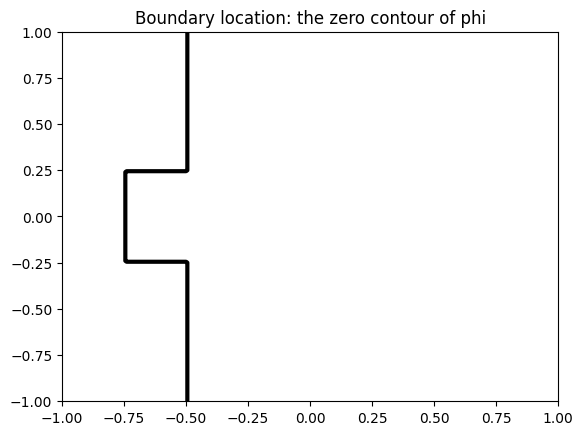

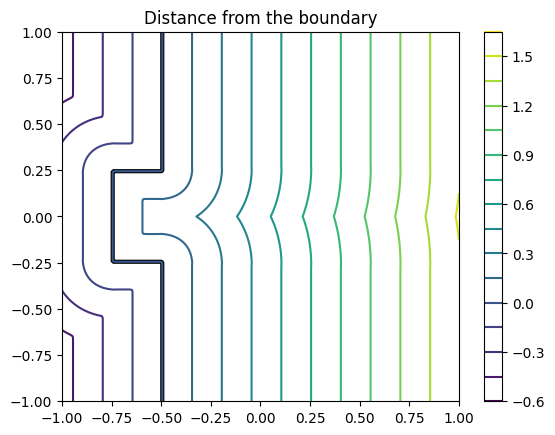

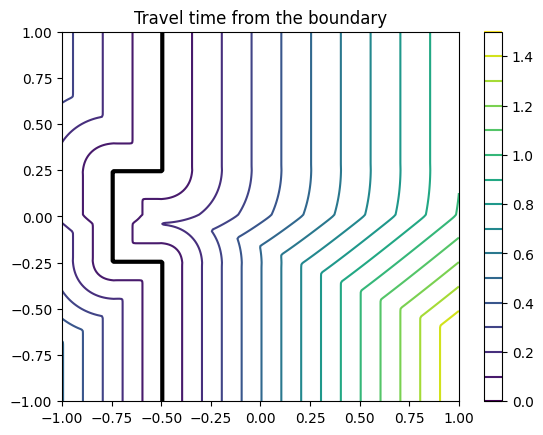

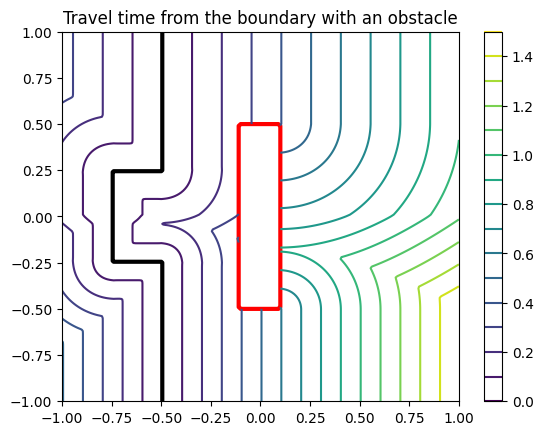

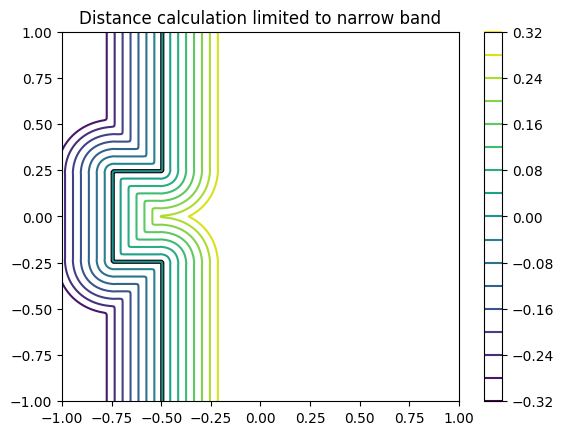

In [1]:
import numpy as np
import pylab as plt
import skfmm

X, Y = np.meshgrid(np.linspace(-1,1,201), np.linspace(-1,1,201))
phi = -1*np.ones_like(X)

phi[X>-0.5] = 1
phi[np.logical_and(np.abs(Y)<0.25, X>-0.75)] = 1
plt.contour(X, Y, phi,[0], linewidths=(3), colors='black')
plt.title('Boundary location: the zero contour of phi')
plt.savefig('2d_phi.png')
plt.show()

d = skfmm.distance(phi, dx=1e-2)
plt.title('Distance from the boundary')
plt.contour(X, Y, phi,[0], linewidths=(3), colors='black')
plt.contour(X, Y, d, 15)
plt.colorbar()
plt.savefig('2d_phi_distance.png')
plt.show()

speed = np.ones_like(X)
speed[Y>0] = 1.5
t = skfmm.travel_time(phi, speed, dx=1e-2)

plt.title('Travel time from the boundary')
plt.contour(X, Y, phi,[0], linewidths=(3), colors='black')
plt.contour(X, Y, t, 15)
plt.colorbar()
plt.savefig('2d_phi_travel_time.png')
plt.show()

mask = np.logical_and(abs(X)<0.1, abs(Y)<0.5)
phi  = np.ma.MaskedArray(phi, mask)
t    = skfmm.travel_time(phi, speed, dx=1e-2)
plt.title('Travel time from the boundary with an obstacle')
plt.contour(X, Y, phi, [0], linewidths=(3), colors='black')
plt.contour(X, Y, phi.mask, [0], linewidths=(3), colors='red')
plt.contour(X, Y, t, 15)
plt.colorbar()
plt.savefig('2d_phi_travel_time_mask.png')
plt.show()

phi = -1 * np.ones_like(X)
phi[X > -0.5] = 1
phi[np.logical_and(np.abs(Y) < 0.25, X > -0.75)] = 1
d = skfmm.distance(phi, dx=1e-2, narrow=0.3)
plt.title('Distance calculation limited to narrow band')
plt.contour(X, Y, phi, [0], linewidths=(3), colors='black')
plt.contour(X, Y, d, 15)
plt.colorbar()
plt.savefig('2d_phi_distance_narrow.png')
plt.show()

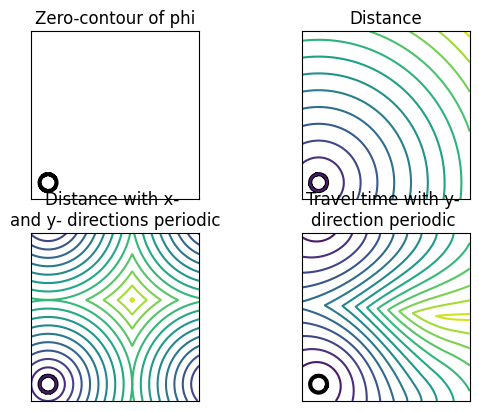

In [2]:
import numpy as np
import pylab as plt
import skfmm

X, Y = np.meshgrid(np.linspace(-1,1,501), np.linspace(-1,1,501))
phi = (X+0.8)**2+(Y+0.8)**2 - 0.01
speed = 1+X**2+Y**2

plt.subplot(221)
plt.title("Zero-contour of phi")
plt.contour(X, Y, phi, [0], colors='black', linewidths=(3))
plt.gca().set_aspect(1)
plt.xticks([]); plt.yticks([])

plt.subplot(222)
plt.title("Distance")
plt.contour(X, Y, phi, [0], colors='black', linewidths=(3))
plt.contour(X, Y, skfmm.distance(phi, dx=2.0/500), 15)
plt.gca().set_aspect(1)
plt.xticks([]); plt.yticks([])

plt.subplot(223)
plt.title("Distance with x- \nand y- directions periodic")
plt.contour(X, Y, phi, [0], colors='black', linewidths=(3))
plt.contour(X, Y, skfmm.distance(phi, dx=2.0/500, periodic=True), 15)
plt.gca().set_aspect(1)
plt.xticks([]); plt.yticks([])

plt.subplot(224)
plt.title("Travel time with y- \ndirection periodic ")
plt.contour(X, Y, phi, [0], colors='black', linewidths=(3))
plt.contour(X, Y, skfmm.travel_time(phi, speed, dx=2.0/500, periodic=(1,0)), 15)
plt.gca().set_aspect(1)
plt.xticks([]); plt.yticks([])

plt.show()


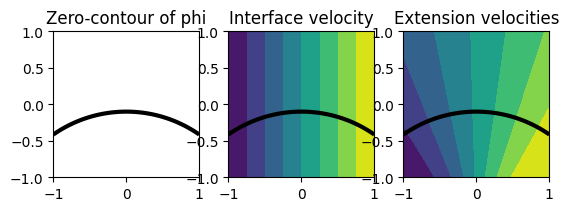

In [3]:
import numpy as np
import pylab as plt
from skfmm import extension_velocities

N     = 150
X, Y  = np.meshgrid(np.linspace(-1, 1, N), np.linspace(-1, 1, N))
r     = 1.75
dx    = 2.0 / (N - 1)
phi   = (X) ** 2 + (Y+1.85) ** 2 - r ** 2
speed = X+1.25
d, f_ext = extension_velocities(phi, speed, dx)


plt.subplot(131)
plt.title("Zero-contour of phi")
plt.contour(X, Y, phi,[0], colors='black', linewidths=(3))
plt.gca().set_aspect(1)

plt.subplot(132)
plt.title("Interface velocity")
plt.contour(X, Y, phi,[0], colors='black', linewidths=(3))
plt.contourf(X, Y, speed)
plt.gca().set_aspect(1)

plt.subplot(133)
plt.title("Extension velocities")
plt.contour(X, Y, phi,[0], colors='black', linewidths=(3))
plt.contourf(X, Y, f_ext)
plt.gca().set_aspect(1)

plt.show()
